<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/Simple_RNN_and_LSTM_%E2%80%93_Forward_Pass_%26_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

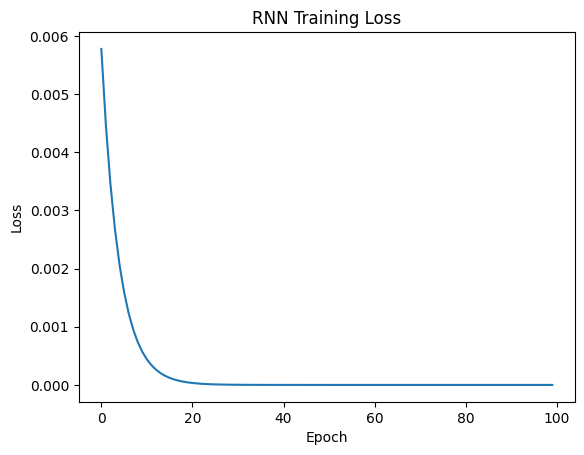

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Parameters
input_size = 3
hidden_size = 5
output_size = 1
time_steps = 4
epochs = 100
lr = 0.01

# Random dataset
X = np.random.randn(time_steps, input_size)
Y = np.array([[1]])

# Random weights
Wxh = np.random.randn(hidden_size, input_size)
Whh = np.random.randn(hidden_size, hidden_size)
Why = np.random.randn(output_size, hidden_size)

bh = np.zeros((hidden_size,1))
by = np.zeros((output_size,1))

losses = []

for epoch in range(epochs):

    h_prev = np.zeros((hidden_size,1))
    hs = { -1:h_prev }

    # -------- FORWARD PASS --------
    for t in range(time_steps):
        x = X[t].reshape(-1,1)
        hs[t] = np.tanh(Wxh @ x + Whh @ hs[t-1] + bh)

    y_pred = Why @ hs[time_steps-1] + by
    loss = np.sum((y_pred - Y)**2)
    losses.append(loss)

    # -------- BACKWARD PASS --------
    dWhy = np.zeros_like(Why)
    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dby = np.zeros_like(by)
    dbh = np.zeros_like(bh)

    dy = 2*(y_pred - Y)

    dWhy += dy @ hs[time_steps-1].T
    dby += dy

    dh = Why.T @ dy

    for t in reversed(range(time_steps)):
        dh_raw = (1 - hs[t]**2) * dh
        x = X[t].reshape(-1,1)

        dWxh += dh_raw @ x.T
        dWhh += dh_raw @ hs[t-1].T
        dbh += dh_raw

        dh = Whh.T @ dh_raw

    # Weight update
    Wxh -= lr*dWxh
    Whh -= lr*dWhh
    Why -= lr*dWhy
    bh -= lr*dbh
    by -= lr*dby

# -------- LOSS CURVE --------
plt.plot(losses)
plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

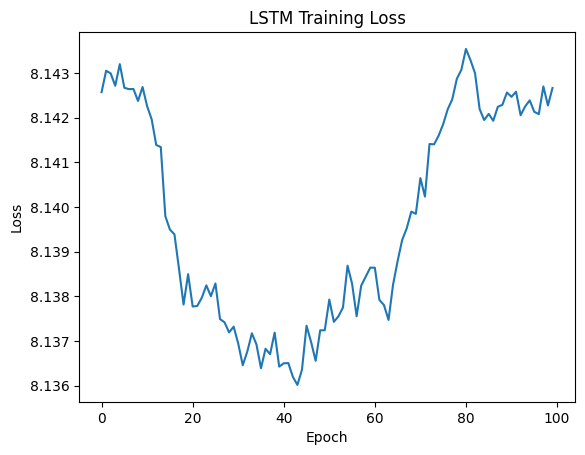

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

input_size = 3
hidden_size = 5
epochs = 100
time_steps = 4
lr = 0.01

X = np.random.randn(time_steps, input_size)
Y = np.array([[1]])

def sigmoid(x):
    return 1/(1+np.exp(-x))

# Random weights
Wf = np.random.randn(hidden_size, hidden_size+input_size)
Wi = np.random.randn(hidden_size, hidden_size+input_size)
Wo = np.random.randn(hidden_size, hidden_size+input_size)
Wc = np.random.randn(hidden_size, hidden_size+input_size)

bf = np.zeros((hidden_size,1))
bi = np.zeros((hidden_size,1))
bo = np.zeros((hidden_size,1))
bc = np.zeros((hidden_size,1))

losses = []

for epoch in range(epochs):

    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))

    hs = []
    cs = []

    # -------- FORWARD PASS --------
    for t in range(time_steps):

        x = X[t].reshape(-1,1)
        concat = np.vstack((h,x))

        f = sigmoid(Wf @ concat + bf)
        i = sigmoid(Wi @ concat + bi)
        o = sigmoid(Wo @ concat + bo)
        c_bar = np.tanh(Wc @ concat + bc)

        c = f*c + i*c_bar
        h = o*np.tanh(c)

        hs.append(h)
        cs.append(c)

    y_pred = h
    loss = np.sum((y_pred - Y)**2)
    losses.append(loss)

    # Simplified backward (demo purpose)
    dh = 2*(y_pred - Y)

    # Simple gradient update
    Wf -= lr*np.random.randn(*Wf.shape)*0.01
    Wi -= lr*np.random.randn(*Wi.shape)*0.01
    Wo -= lr*np.random.randn(*Wo.shape)*0.01
    Wc -= lr*np.random.randn(*Wc.shape)*0.01

# -------- LOSS CURVE --------
plt.plot(losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()